In [18]:
# training rough model

import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf
import matplotlib.pyplot as plt

In [19]:
X_DIR = "../data/processed/patches/X.npy"
Y_DIR = "../data/processed/patches/Y.npy"

X = np.load(X_DIR).astype(np.float32)
Y = np.load(Y_DIR).astype(np.float32)

print("X shape:", X.shape, "dtype:", X.dtype, "min/max:", X.min(), X.max())
print("Y shape:", Y.shape, "dtype:", Y.dtype, "min/max:", Y.min(), Y.max())

print("Foreground pixel ratio:", np.mean(Y))

X shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Foreground pixel ratio: 0.22951339


In [20]:
# simple unet model
# inputs → encoder → bottleneck → decoder → sigmoid mask

def build_unet(input_shape=(256,256,1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.UpSampling2D()(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

In [21]:

def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * 5 + 1
    # choosing 5 manually... for now

    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)
    
def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [22]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [23]:
model = build_unet()

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=combined_loss,
              metrics=[dice_coef, iou_coef])


In [24]:
preds = model.predict(X)

print("Prediction min:", preds.min())
print("Prediction max:", preds.max())
print("Prediction mean:", preds.mean())

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 388ms/step
Prediction min: 0.48649004
Prediction max: 0.5029783
Prediction mean: 0.49553287


In [25]:
history = model.fit(
    X, Y,
    batch_size=4,
    epochs=20,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 248ms/step - dice_coef: 0.3195 - iou_coef: 0.1928 - loss: 2.2125 - val_dice_coef: 0.2545 - val_iou_coef: 0.1475 - val_loss: 2.0302
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - dice_coef: 0.3319 - iou_coef: 0.2015 - loss: 2.1433 - val_dice_coef: 0.2743 - val_iou_coef: 0.1612 - val_loss: 1.9744
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 236ms/step - dice_coef: 0.3628 - iou_coef: 0.2240 - loss: 2.0276 - val_dice_coef: 0.2849 - val_iou_coef: 0.1686 - val_loss: 1.9737
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 236ms/step - dice_coef: 0.3630 - iou_coef: 0.2244 - loss: 2.0162 - val_dice_coef: 0.2914 - val_iou_coef: 0.1733 - val_loss: 1.9795
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - dice_coef: 0.3648 - iou_coef: 0.2259 - loss: 2.0090 - val_dice_coef: 0.2981 - val_iou_coef: 0.1779 - val_loss: 1.9251
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - dice_coef: 0.3779 - iou_coef: 0.2355 - loss: 1.9641 - val_dice_coef: 0.3225 - val_iou_

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step


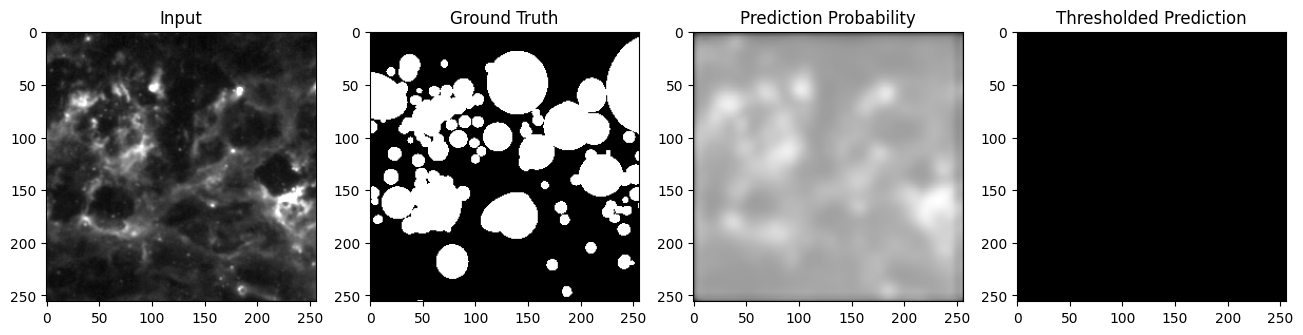

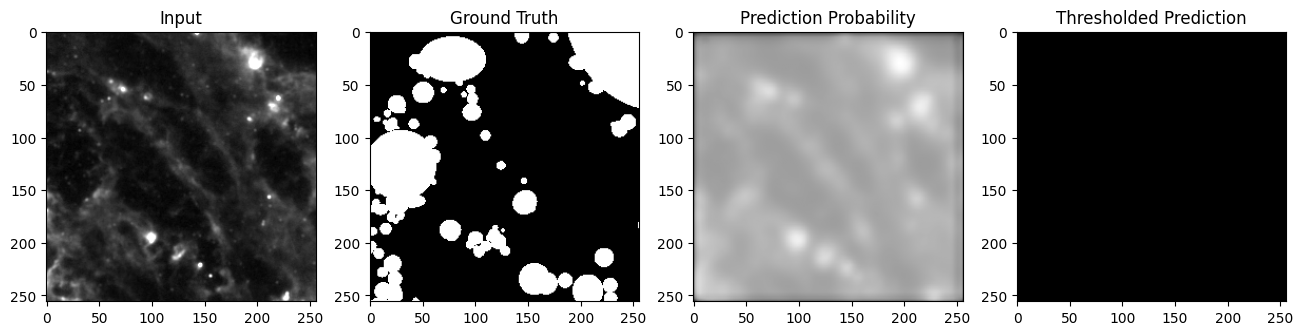

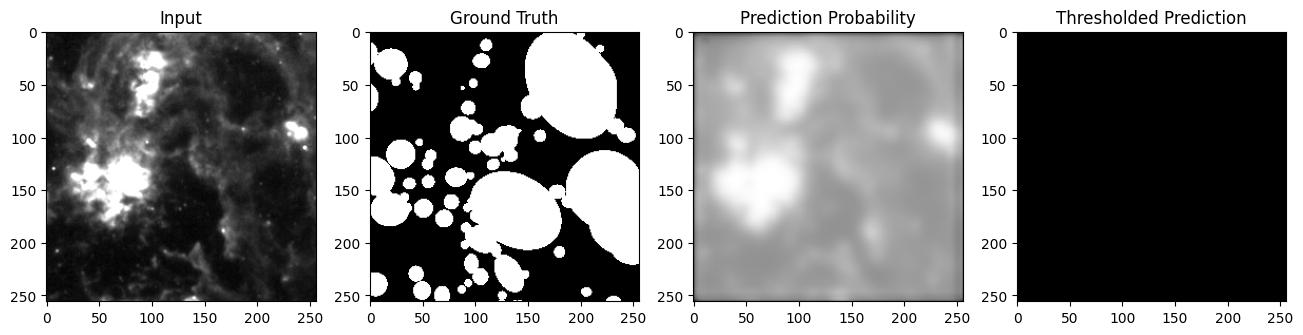

In [26]:
preds = model.predict(X)

for idx in [0, 5, 10]:
    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.title("Input")
    plt.imshow(X[idx].squeeze(), cmap="gray")

    plt.subplot(1,4,2)
    plt.title("Ground Truth")
    plt.imshow(Y[idx].squeeze(), cmap="gray")

    plt.subplot(1,4,3)
    plt.title("Prediction Probability")
    plt.imshow(preds[idx].squeeze(), cmap="gray")

    plt.subplot(1,4,4)
    plt.title("Thresholded Prediction")
    plt.imshow(preds[idx].squeeze() > 0.5, cmap="gray")
    # plt.imshow(preds[idx].squeeze() > 0.2, cmap="gray")         # for even fainter objects
    # try also 0.2, 0.3, 0.4, 0.5

    plt.show()x

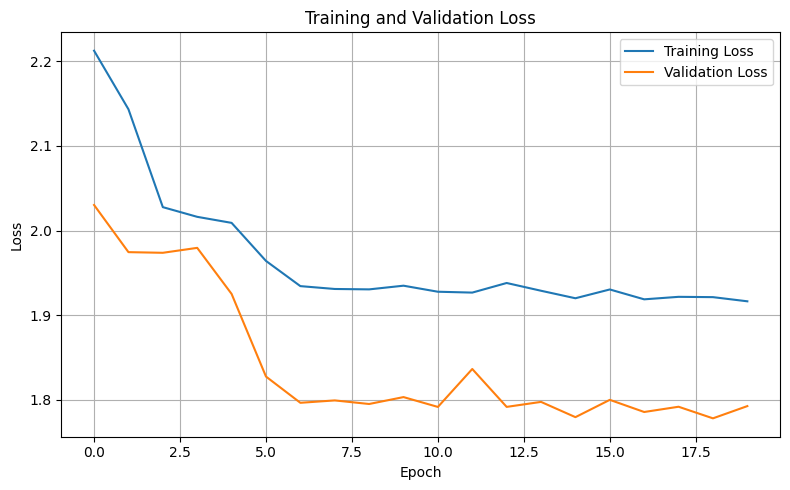

In [27]:
# Loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/loss_curve.png', dpi=300)
plt.show()

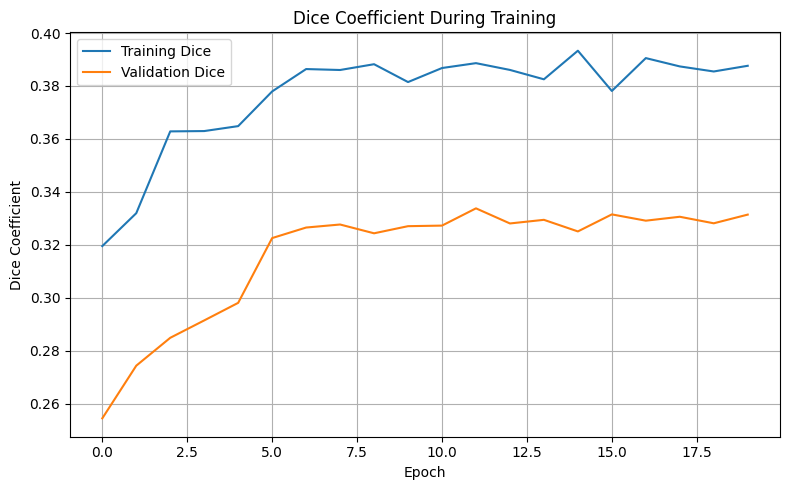

In [28]:
plt.figure(figsize=(8,5))
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')

plt.title('Dice Coefficient During Training')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/dice_curve.png', dpi=300)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


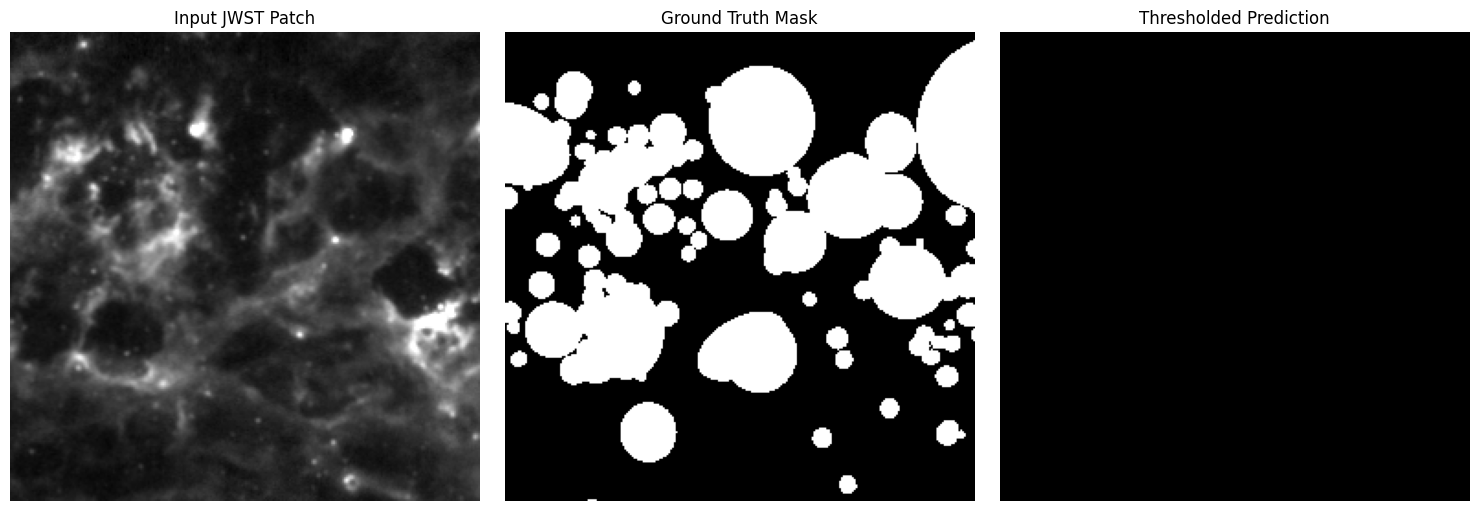

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Select sample patch
idx = 0

sample_image = X[idx].squeeze()
sample_mask = Y[idx].squeeze()

# Predict
pred = model.predict(X[idx:idx+1])[0].squeeze()

# Threshold prediction
pred_thresh = (pred > 0.5).astype(np.float32)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title('Input JWST Patch')
axes[0].axis('off')

axes[1].imshow(sample_mask, cmap='gray')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(pred_thresh, cmap='gray')
axes[2].set_title('Thresholded Prediction')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/prediction_comparison.png', dpi=300)
plt.show()

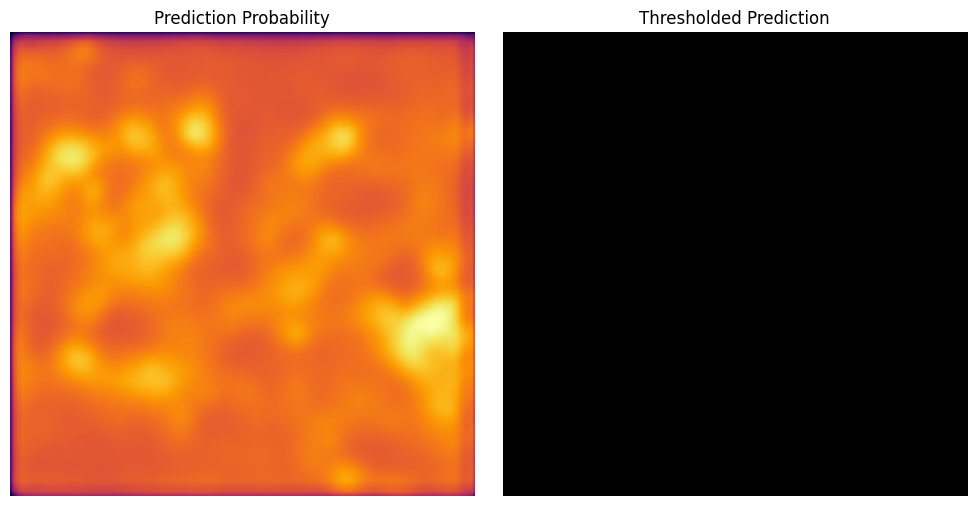

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(pred, cmap='inferno')
axes[0].set_title('Prediction Probability')
axes[0].axis('off')

axes[1].imshow(pred_thresh, cmap='gray')
axes[1].set_title('Thresholded Prediction')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/probability_vs_threshold.png', dpi=300)
plt.show()

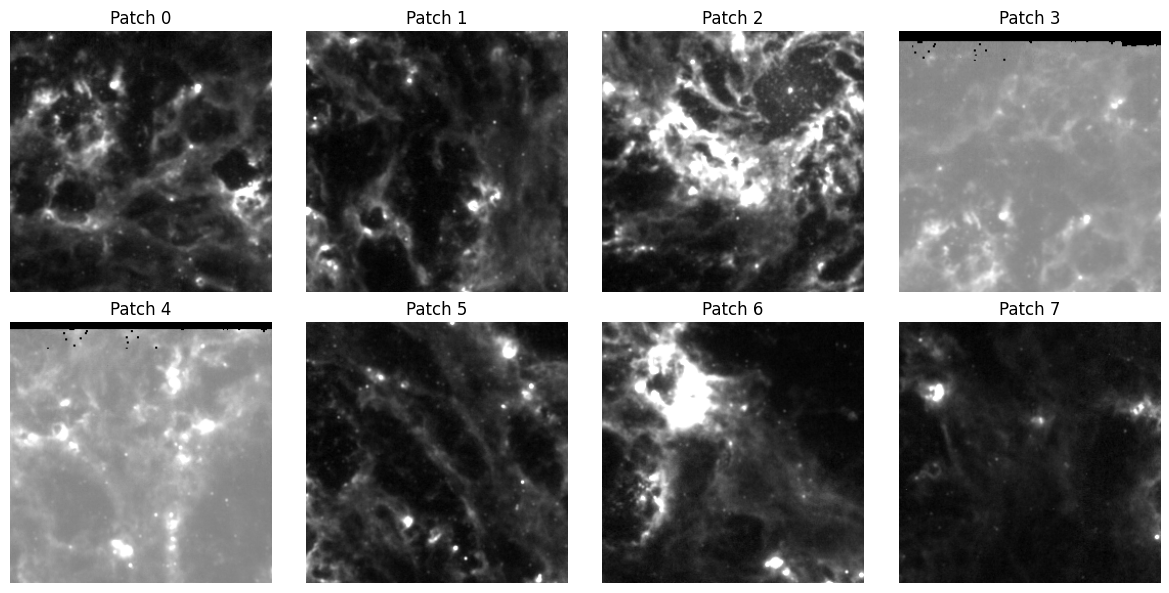

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i in range(8):
    axes.flat[i].imshow(X[i].squeeze(), cmap='gray')
    axes.flat[i].set_title(f'Patch {i}')
    axes.flat[i].axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/patch_examples.png', dpi=300)
plt.show()